In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('train_data.csv')

In [3]:
features = [
    # encoded station/service
    'StationCode_TE',
    'Service:Type_Intercity',
    'Service:Type_Intercity direct',
    'Service:Type_Sprinter',
    # temporal
    'Hour_sin',
    'Hour_cos',
    'DayOfWeek_sin',
    'DayOfWeek_cos',
    'Month_sin',
    'Month_cos',
    'IsWeekend',
    'RushHour',
    # operational context
    'StationTraffic',
    'Stop:Platform change',
    'arrival_scheduled',
    'departure_scheduled',
    # weather
    'Wind Direction',
    'Hourly Mean Wind Speed',
    'Wind Speed last 10 Minutes',
    'Max Wind Speed',
    'Temperature',
    'Dew Point temperature',
    'Sunshine Duration',
    'Global Radiation',
    'Precipitation Duration',
    'Precipitation Amount',
    'Air Pressure',
    'Horizontal Visibility',
    'Cloud Cover',
    'Humidity',
    'Fog',
    'Rainfall',
    'Snowfall',
    'Thunder',
    'Hail',
]

target = "is_cancelled"

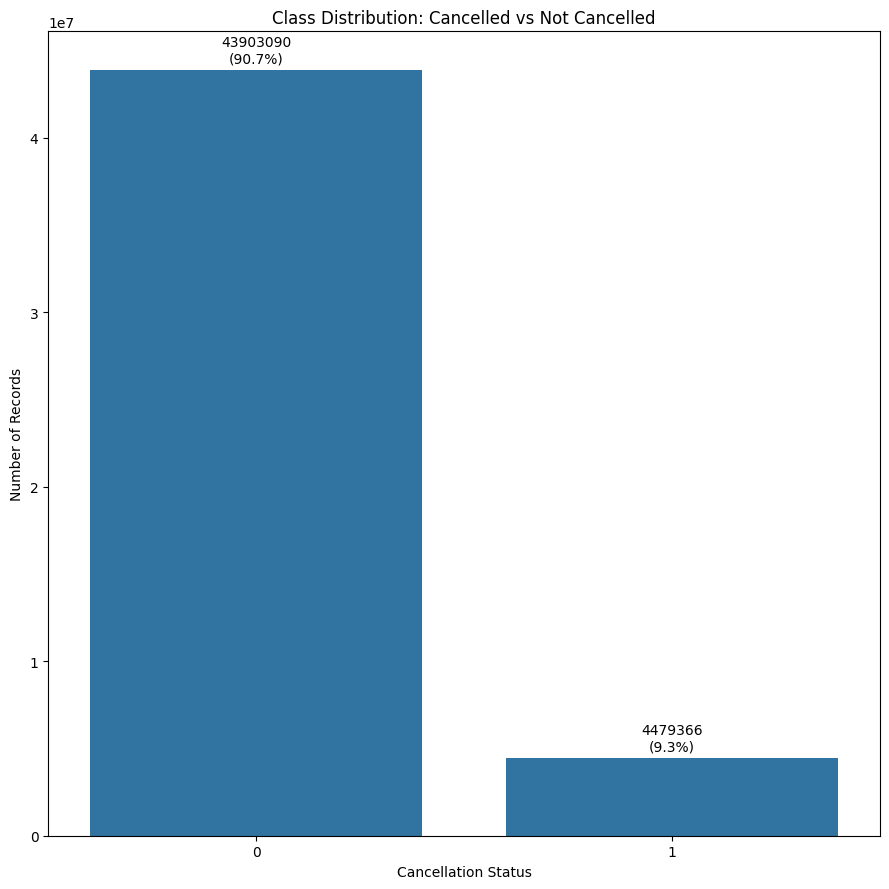

is_cancelled
0    43903090
1     4479366
Name: count, dtype: int64
is_cancelled
0    90.74
1     9.26
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(9, 9))

ax = sns.countplot(data=train, x=target)

total = len(train)

for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100

    ax.annotate(
        f"{count}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.title("Class Distribution: Cancelled vs Not Cancelled")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

print(train[target].value_counts())
print(train[target].value_counts(normalize=True).mul(100).round(2))

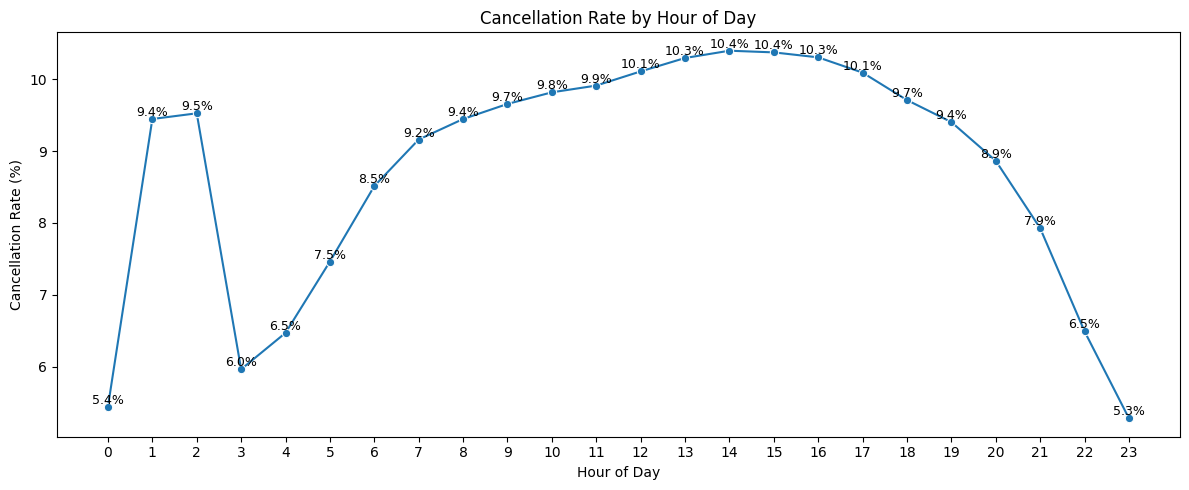

In [10]:
# Calculate hour without copying the full dataset
hour = (
    np.arctan2(train["Hour_sin"], train["Hour_cos"]) * 24 / (2 * np.pi)
) % 24

# Replace inf/-inf with NaN
hour = hour.replace([np.inf, -np.inf], np.nan)

# Keep only rows where hour and target are valid
valid_mask = hour.notna() & train[target].notna()

hourly_cancel = (
    pd.DataFrame({
        "Hour": hour[valid_mask].round().astype(int) % 24,
        target: train.loc[valid_mask, target]
    })
    .groupby("Hour")[target]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(12, 5))

ax = sns.lineplot(
    data=hourly_cancel,
    x="Hour",
    y=target,
    marker="o"
)

# Add numbers on the graph
for _, row in hourly_cancel.iterrows():
    ax.text(
        row["Hour"],
        row[target],
        f"{row[target]:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Cancellation Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

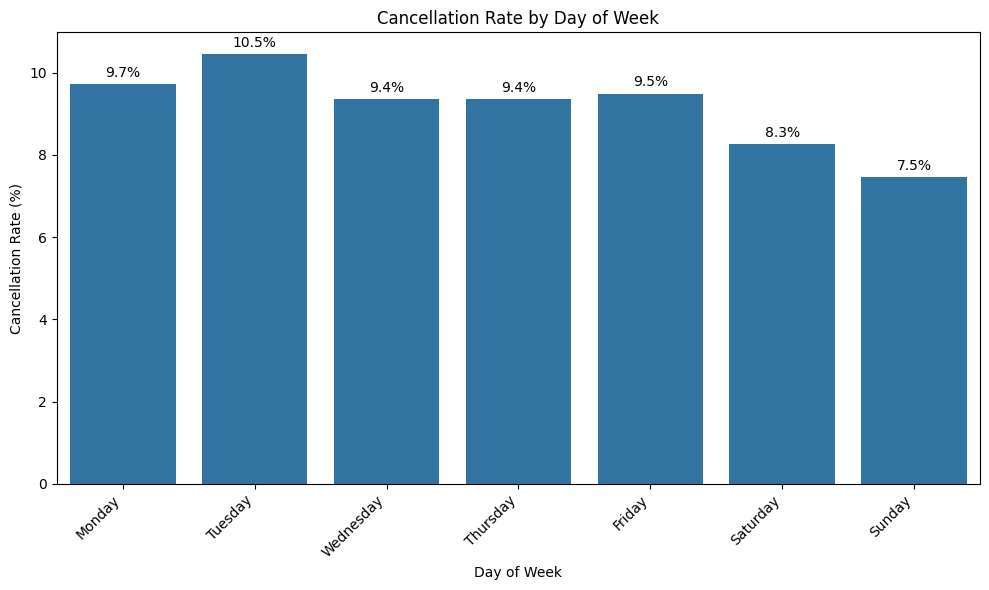

In [14]:
dayofweek = (
    np.arctan2(train["DayOfWeek_sin"], train["DayOfWeek_cos"]) * 7 / (2 * np.pi)
) % 7

# Replace inf/-inf with NaN
dayofweek = dayofweek.replace([np.inf, -np.inf], np.nan)

# Keep only valid rows
valid_mask = dayofweek.notna() & train[target].notna()

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

daily_cancel = (
    pd.DataFrame({
        "DayOfWeek": dayofweek[valid_mask].round().astype(int) % 7,
        target: train.loc[valid_mask, target]
    })
    .assign(DayOfWeekName=lambda x: x["DayOfWeek"].map(day_names))
    .groupby(["DayOfWeek", "DayOfWeekName"])[target]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("DayOfWeek")
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=daily_cancel,
    x="DayOfWeekName",
    y=target
)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Cancellation Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

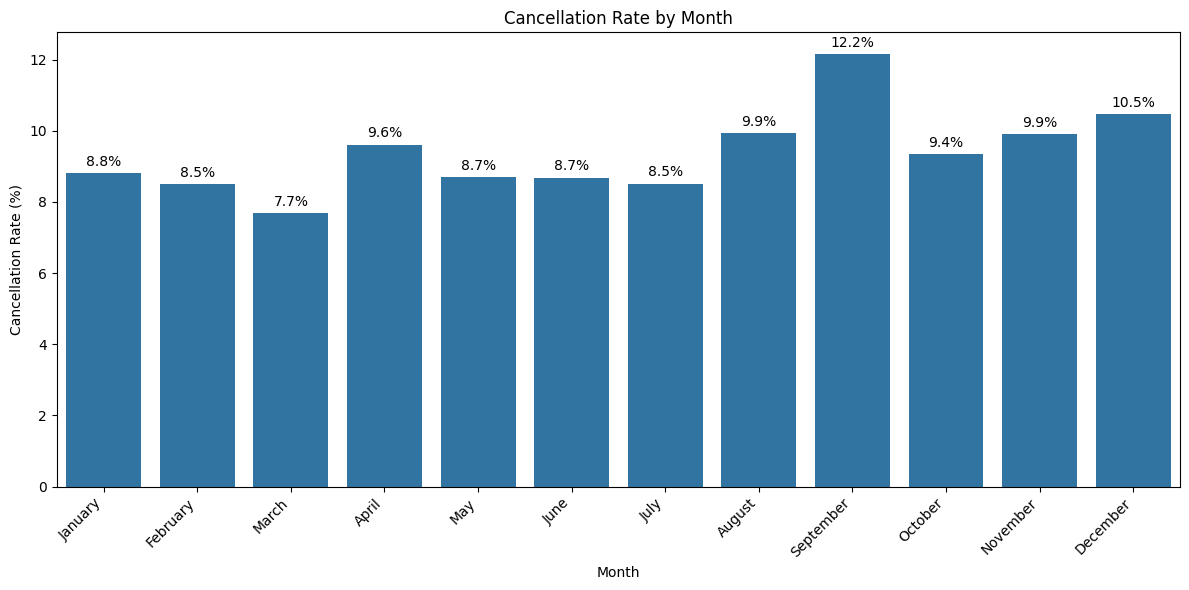

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

month = (
    np.arctan2(train["Month_sin"], train["Month_cos"]) * 12 / (2 * np.pi)
) % 12

# Replace inf/-inf with NaN
month = month.replace([np.inf, -np.inf], np.nan)

# Keep only valid rows
valid_mask = month.notna() & train[target].notna()

# Convert from 0-11 to 1-12
month_clean = month[valid_mask].round().astype(int)
month_clean = month_clean.replace(0, 12)

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_cancel = (
    pd.DataFrame({
        "Month": month_clean,
        target: train.loc[valid_mask, target]
    })
    .assign(MonthName=lambda x: x["Month"].map(month_names))
    .groupby(["Month", "MonthName"])[target]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("Month")
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=monthly_cancel,
    x="MonthName",
    y=target
)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Cancellation Rate by Month")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

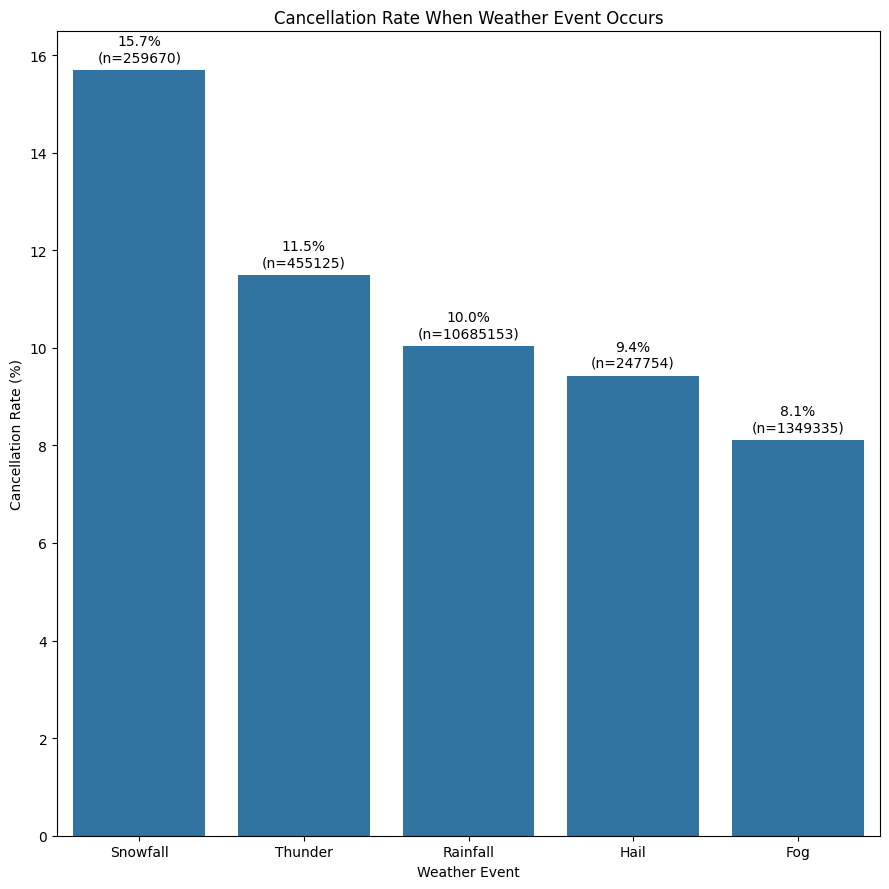

,Weather Event,Cancellation Rate (%),Number of Records
2,Snowfall,15.701082,259670
3,Thunder,11.486954,455125
1,Rainfall,10.042084,10685153
4,Hail,9.431533,247754
0,Fog,8.119259,1349335


In [21]:
weather_event_cols = [
    "Fog",
    "Rainfall",
    "Snowfall",
    "Thunder",
    "Hail"
]

weather_event_rates = []

for col in weather_event_cols:
    rate = train.groupby(col)[target].mean().mul(100)
    
    if 1 in rate.index:
        weather_event_rates.append({
            "Weather Event": col,
            "Cancellation Rate (%)": rate.loc[1],
            "Number of Records": train[train[col] == 1].shape[0]
        })

weather_event_rates = pd.DataFrame(weather_event_rates)

weather_event_rates = weather_event_rates.sort_values(
    "Cancellation Rate (%)",
    ascending=False
)

plt.figure(figsize=(9, 9))

ax = sns.barplot(
    data=weather_event_rates,
    x="Weather Event",
    y="Cancellation Rate (%)"
)

# Add rate and record count labels
for p, (_, row) in zip(ax.patches, weather_event_rates.iterrows()):
    rate = row["Cancellation Rate (%)"]
    records = int(row["Number of Records"])

    ax.annotate(
        f"{rate:.1f}%\n(n={records})",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.title("Cancellation Rate When Weather Event Occurs")
plt.xlabel("Weather Event")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

display(weather_event_rates)

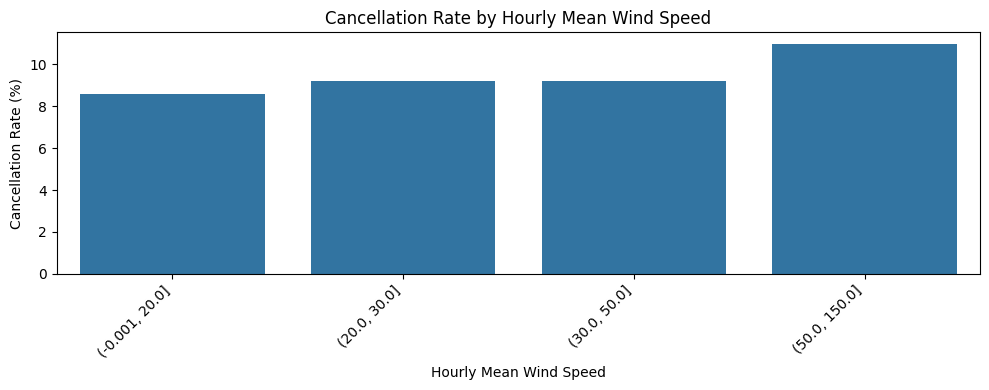

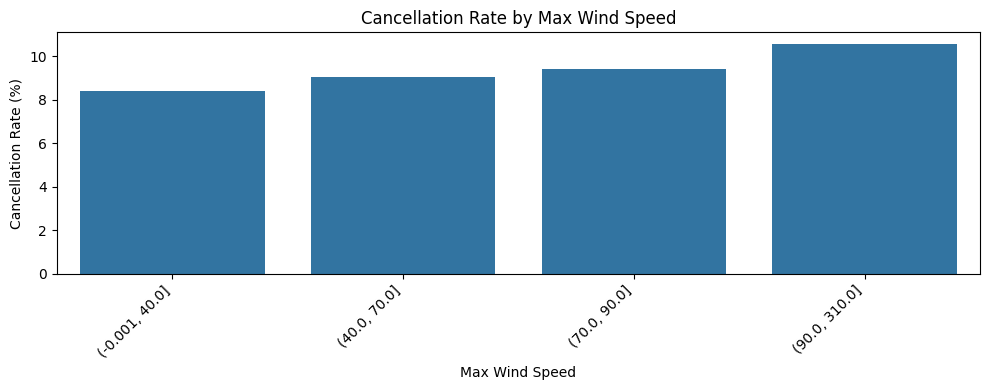

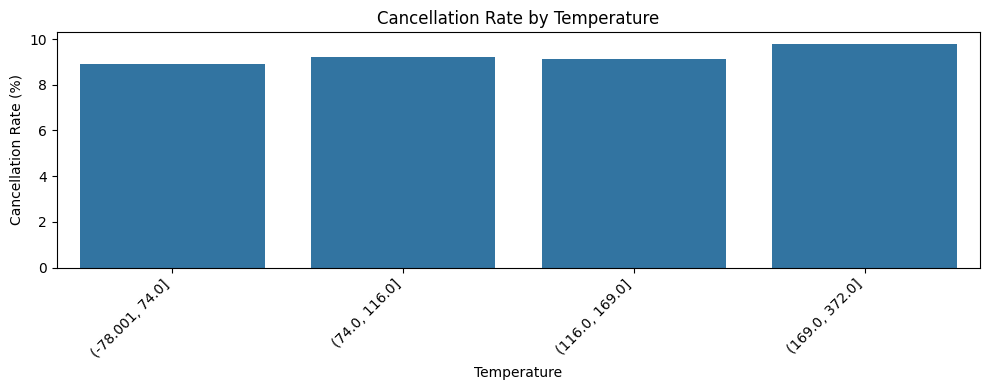

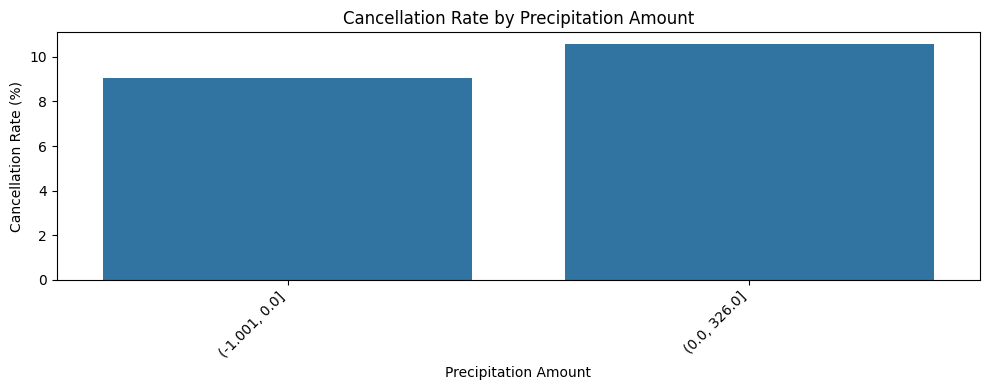

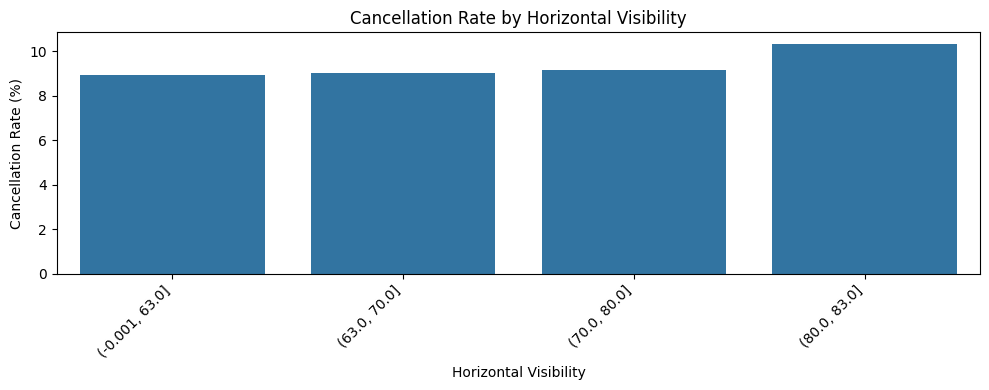

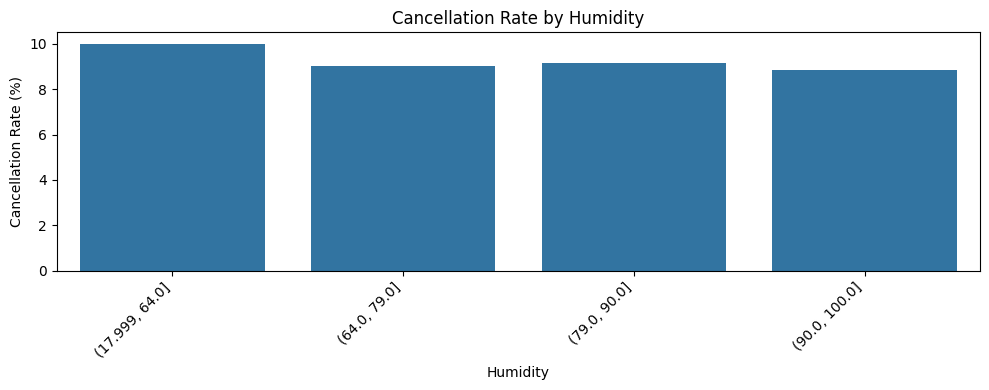

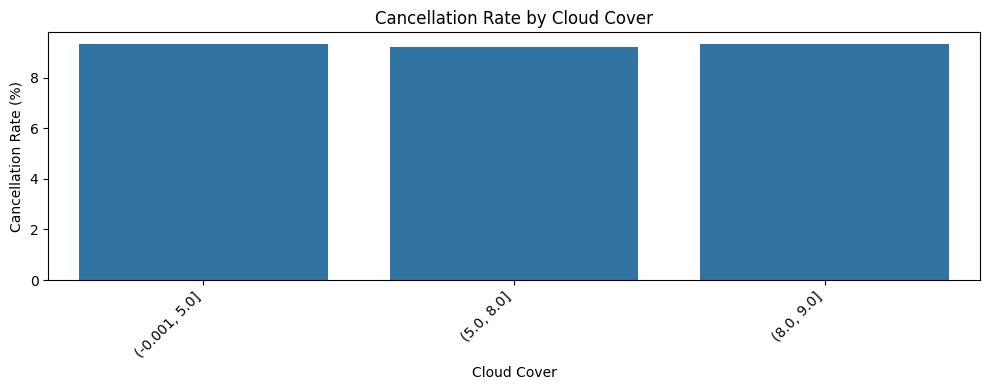

In [19]:
numeric_weather_cols = [
    "Hourly Mean Wind Speed",
    "Max Wind Speed",
    "Temperature",
    "Precipitation Amount",
    "Horizontal Visibility",
    "Humidity",
    "Cloud Cover"
]

for col in numeric_weather_cols:
    temp = train[[col, target]].dropna().copy()
    
    temp[f"{col}_bin"] = pd.qcut(
        temp[col],
        q=4,
        duplicates="drop"
    )
    
    cancel_by_bin = (
        temp
        .groupby(f"{col}_bin")[target]
        .mean()
        .mul(100)
        .reset_index()
    )
    
    plt.figure(figsize=(10, 4))
    
    sns.barplot(
        data=cancel_by_bin,
        x=f"{col}_bin",
        y=target
    )
    
    plt.title(f"Cancellation Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Cancellation Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

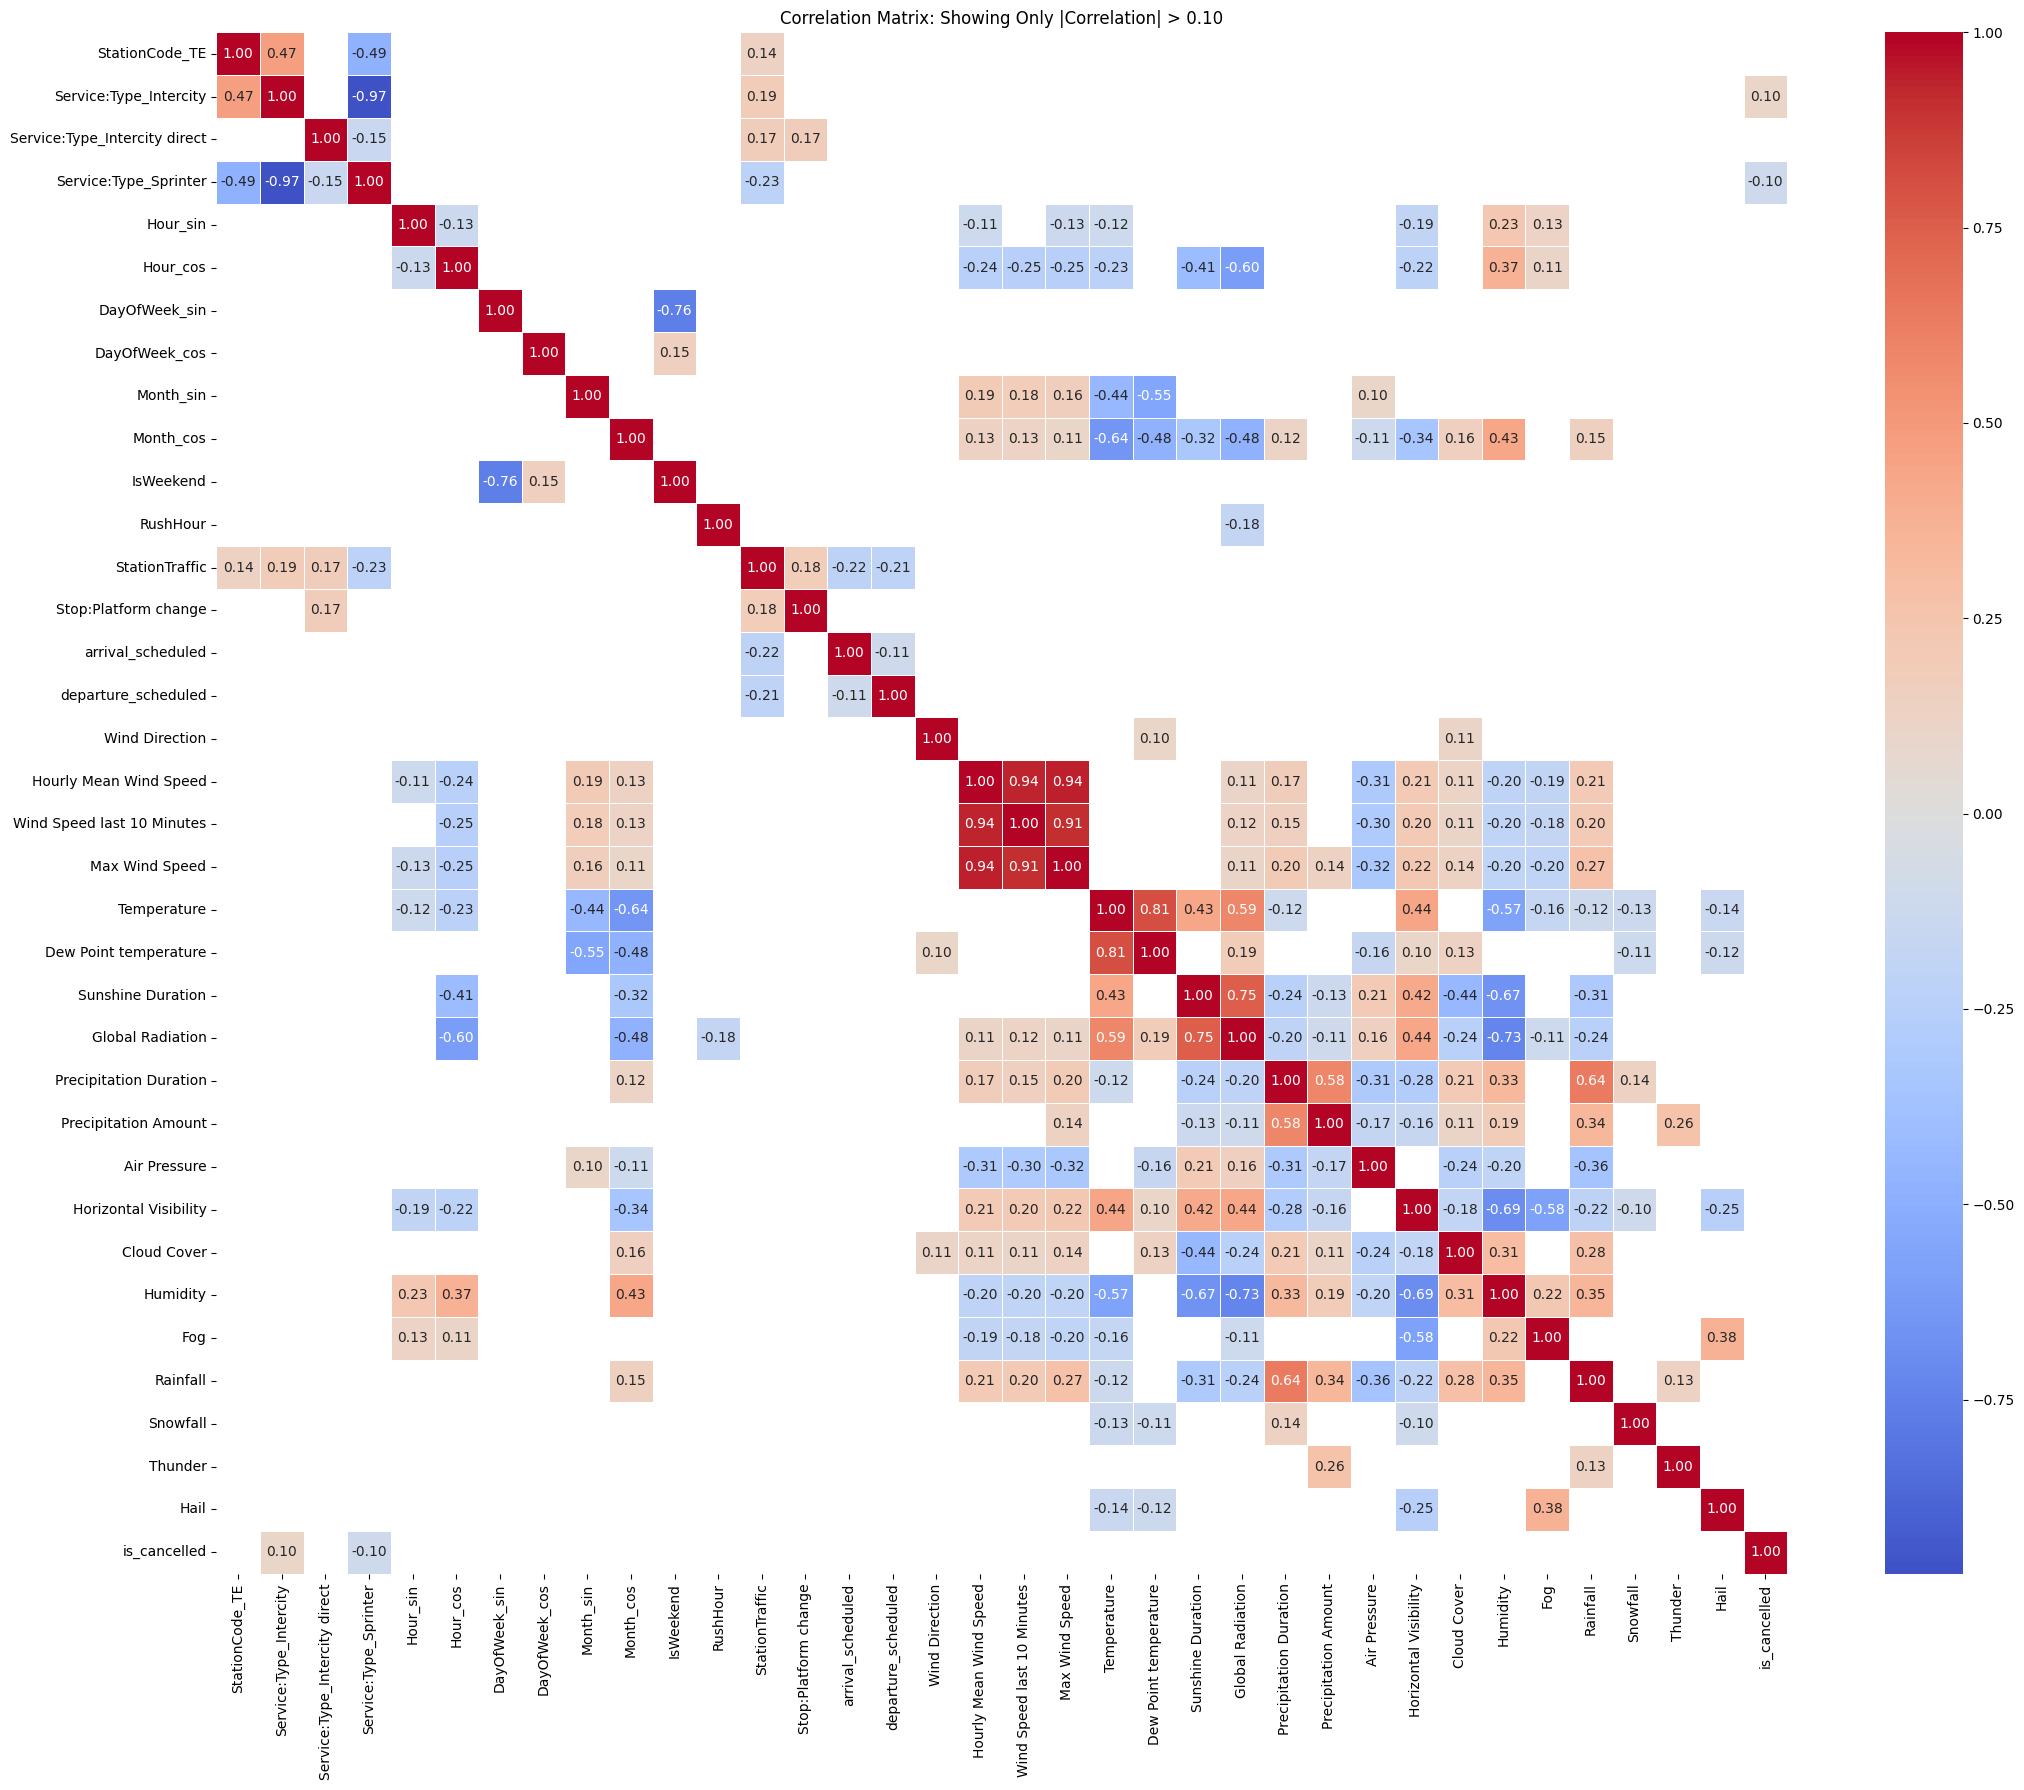

In [20]:
corr_cols = features + [target]

corr = train[corr_cols].corr(numeric_only=True)

# Hide weak correlations between -0.10 and 0.10
mask = corr.abs() <= 0.10

plt.figure(figsize=(22, 18))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix: Showing Only |Correlation| > 0.10")
plt.tight_layout()
plt.show()